In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *


$\sigma$
$\varepsilon$

<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:120: SyntaxWarning: invalid escape sequence '\e'
<>:121: SyntaxWarning: invalid escape sequence '\s'
<>:146: SyntaxWarning: invalid escape sequence '\e'
<>:147: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:120: SyntaxWarning: invalid escape sequence '\e'
<>:121: SyntaxWarning: invalid escape sequence '\s'
<>:146: SyntaxWarning: invalid escape sequence '\e'
<>:147: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1006/1058516190.py:44: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("Dehnung $\epsilon$")
/tmp/ipykernel_1006/1058516190.py:45: SyntaxWarning: invali

3.198+/-0.014


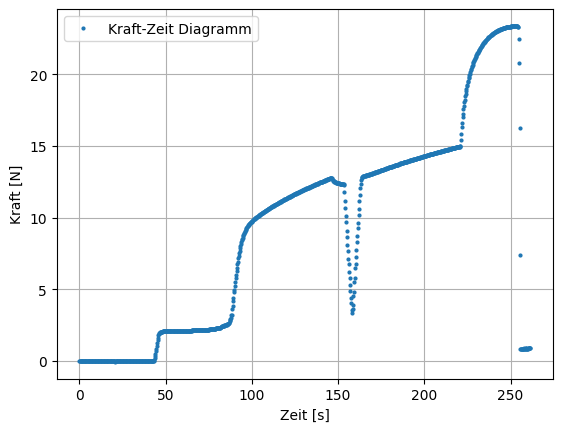

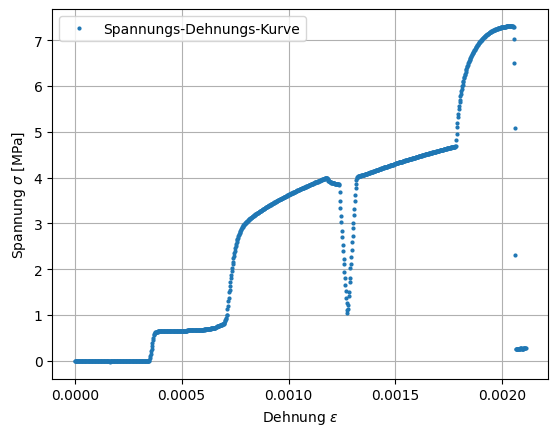

e-Modul:
(6.99+/-0.11)e+04


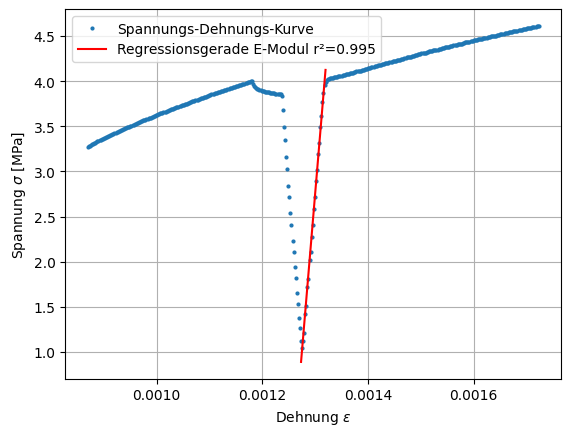

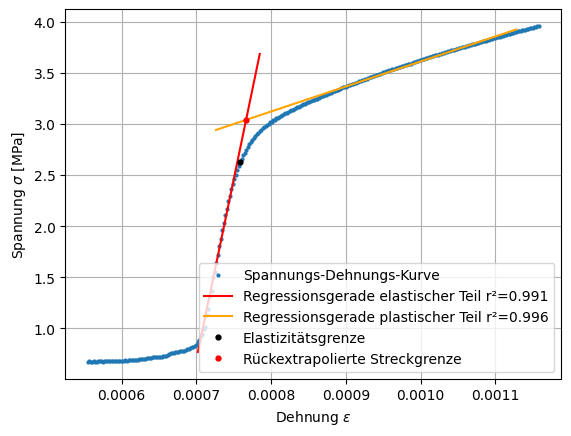

wert elastizitätsgrenze:
0.000758579616190937
2.629+/-0.012
Wert rückextrapolierte streckgrenze:
0.0007666472907595551
3.0430847253452207

das is das nicht auswertbare diagramm:


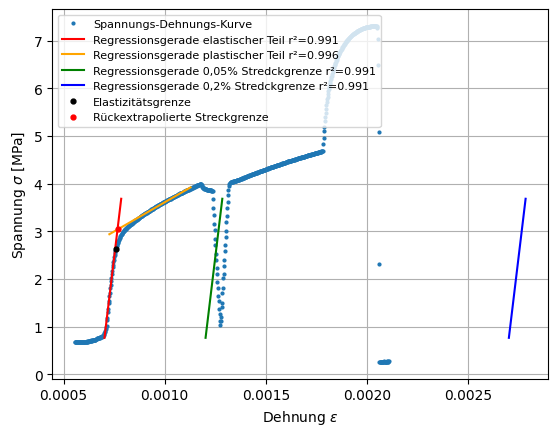

In [5]:
# 1. Experiment: Spannungs-Dehnungs-Kurve von Aluminium

#daten zugmaschine:
v = 0.05/60                 #[mm/min] --> [mm/s]
L0 = ufloat(103.35, 0.05)             #[mm]


#messung querschnitt draht
a = unp.uarray([2.02, 2.01, 2.02, 2.02, 2.02], 0.01)       #[mm] 
d = np.mean(a)              #durchschnitt der werte [mm]

q = (d/2)**2 * np.pi        #querschnitt [mm²]
print(q)

#umrechnungsfaktor
u =  1209                       #angezeigter Wert bei 1kg gewicht

#daten auslesen
df = pd.read_csv("PS1_Do01_SoSe26.csv", sep=",", decimal=".", engine="python")
t = df["T"].to_numpy()
wert = df["x"].to_numpy()

F = wert/u                  #messwert mit umrechnungsfaktor umgerechnet in Kraft [N]

#diagramm zeichnen
plt.figure()
plt.plot(t, F, 'o', markersize=2, label="Kraft-Zeit Diagramm")
plt.xlabel("Zeit [s]")
plt.ylabel("Kraft [N]")
plt.legend()
plt.grid(True)
plt.show()

#umrechnung spannung:
sigma = F/q                 #[MPa]

#umrechnung dehnung:
epsilon = (v * t)/unp.nominal_values(L0)        #einheitslos
epsilon_nom = unp.nominal_values(epsilon)

#spannungs-dehnungs diagramm zeichnen
plt.figure()
plt.plot(unp.nominal_values(epsilon),unp.nominal_values(sigma), 'o', markersize=2, label="Spannungs-Dehnungs-Kurve")
plt.xlabel("Dehnung $\epsilon$")
plt.ylabel("Spannung $\sigma$ [MPa]")
plt.legend()
plt.grid(True)
plt.show()

#Bestimmung E-Modul - 2. Anstieg!!
t_E = t[631:655]                 #eingeschränkt auf indizes wo der 2. Anstieg ist (aus Datensatz suchen)
wert_E = wert[631:655]

F_E = wert_E/u

sigma_E = F_E/q
epsilon_E = (v * t_E)/L0

slope, intercept, r, _, std = linregress(unp.nominal_values(epsilon_E), unp.nominal_values(sigma_E))

E_Modul = ufloat(slope, std)        #[MPa]
print("e-Modul:")
print(E_Modul)

#darstellung in eingeschränktem Bereich von Diagramm
plt.figure()
plt.plot(unp.nominal_values(epsilon[431:855]), unp.nominal_values(sigma[431:855]), 'o', markersize=2, label="Spannungs-Dehnungs-Kurve")          #epsilon und sigma sinnvoll einschränken
plt.plot(unp.nominal_values(epsilon_E), slope*unp.nominal_values(epsilon_E) + intercept, '-r', label=rf"Regressionsgerade E-Modul r²={r**2:.3f}")         #Regression
plt.xlabel("Dehnung $\epsilon$")
plt.ylabel("Spannung $\sigma$ [MPa]")
plt.legend()
plt.grid(True)
plt.show()

#Bestimmung Streckgrenze - 1. Anstieg!!
t_1 = t[348:376]                 #eingeschränkt auf indizes wo der 1. Anstieg ist (aus Datensatz suchen)
wert_1 = wert[348:376]

F_1 = wert_1/u

sigma_1 = F_1/q
epsilon_1 = (v * t_1)/L0

sigma_1_nom = unp.nominal_values(sigma_1)
epsilon_1_nom =unp.nominal_values(epsilon_1)

reg1 = linregress(epsilon_1_nom, sigma_1_nom)           #linerare regression im 1. Anstieg
plot_epslilon_1 = unp.nominal_values(epsilon[348:390])

a = epsilon_nom[360:390]*reg1.slope + reg1.intercept



t_2 = t[420:560]                 #eingeschränkt auf bereich nach elastizitätsgrenze
wert_2 = wert[420:560]

F_2 = wert_2/u

sigma_2 = F_2/q
epsilon_2 = (v * t_2)/L0

sigma_2_nom = unp.nominal_values(sigma_2)
epsilon_2_nom =unp.nominal_values(epsilon_2)

reg2 = linregress(epsilon_2_nom, sigma_2_nom)
plot_epslilon_2 = unp.nominal_values(epsilon[360:560])

b = epsilon_nom[360:390]*reg2.slope + reg2.intercept


#plot elastizitätsgrenze - da fehlt noch was
plt.figure()
plt.plot(unp.nominal_values(epsilon[275:575]), unp.nominal_values(sigma[275:575]), 'o', markersize=2, label="Spannungs-Dehnungs-Kurve")          #epsilon und sigma sinnvoll einschränken
plt.plot(plot_epslilon_1, reg1.slope*plot_epslilon_1 + reg1.intercept, '-r', label=rf"Regressionsgerade elastischer Teil r²={reg1.rvalue**2:.3f}")      #epsilonwerte sinnvoll einschränken
plt.plot(plot_epslilon_2, reg2.slope*plot_epslilon_2 + reg2.intercept, '-', color="orange", label=rf"Regressionsgerade plastischer Teil r²={reg2.rvalue**2:.3f}")
#plt.plot(plot_epslilon_1+0.0005, reg1.slope*plot_epslilon_1 + reg1.intercept, '-g', label=rf"Regressionsgerade 0,05% Stredckgrenze r²={reg1.rvalue**2:.3f}")
#plt.plot(plot_epslilon_1+0.002, reg1.slope*plot_epslilon_1 + reg1.intercept, '-b', label=rf"Regressionsgerade 0,2% Stredckgrenze r²={reg1.rvalue**2:.3f}")
plt.plot(unp.nominal_values(epsilon[376]), unp.nominal_values(sigma[376]), 'o', markersize=3.5, color="black", label="Elastizitätsgrenze")
plt.plot(unp.nominal_values(epsilon[380]), a[20], 'o', markersize=3.5, color="red", label="Rückextrapolierte Streckgrenze")
plt.xlabel("Dehnung $\epsilon$")
plt.ylabel("Spannung $\sigma$ [MPa]")
plt.legend()
plt.grid(True)
plt.show()

print("wert elastizitätsgrenze:")
print(epsilon[376])
print(sigma[376])
print("Wert rückextrapolierte streckgrenze:")
print(epsilon[380])
print(a[20])
print()


#nicht auswertbare streckgrenzen diagramm
print("das is das nicht auswertbare diagramm:")

plt.figure()
plt.plot(unp.nominal_values(epsilon[275:]), unp.nominal_values(sigma[275:]), 'o', markersize=2, label="Spannungs-Dehnungs-Kurve")          #epsilon und sigma sinnvoll einschränken
plt.plot(plot_epslilon_1, reg1.slope*plot_epslilon_1 + reg1.intercept, '-r', label=rf"Regressionsgerade elastischer Teil r²={reg1.rvalue**2:.3f}")      #epsilonwerte sinnvoll einschränken
plt.plot(plot_epslilon_2, reg2.slope*plot_epslilon_2 + reg2.intercept, '-', color="orange", label=rf"Regressionsgerade plastischer Teil r²={reg2.rvalue**2:.3f}")
plt.plot(plot_epslilon_1+0.0005, reg1.slope*plot_epslilon_1 + reg1.intercept, '-g', label=rf"Regressionsgerade 0,05% Stredckgrenze r²={reg1.rvalue**2:.3f}")
plt.plot(plot_epslilon_1+0.002, reg1.slope*plot_epslilon_1 + reg1.intercept, '-b', label=rf"Regressionsgerade 0,2% Stredckgrenze r²={reg1.rvalue**2:.3f}")
plt.plot(unp.nominal_values(epsilon[376]), unp.nominal_values(sigma[376]), 'o', markersize=3.5, color="black", label="Elastizitätsgrenze")
plt.plot(unp.nominal_values(epsilon[380]), a[20], 'o', markersize=3.5, color="red", label="Rückextrapolierte Streckgrenze")
plt.xlabel("Dehnung $\epsilon$")
plt.ylabel("Spannung $\sigma$ [MPa]")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True)
plt.show()


In [11]:
# 2. Experiment: Bestimmung des Schubmoduls von Aluminium mit dem Torsionspendel

#messung Werte draht
a = (unp.uarray([3.03, 3.02, 3.02, 3.01, 3.02], 0.01))*10**(-3)      #[m] 
d = np.mean(a)              #durchschnitt der werte [m]
r = (d/2)
print(r*1000)
print()

L = ufloat(0.651, 0.005)              #[m]

#abstände für messungen und massen
l1 = ufloat(0.050, 0.002)             #[m] mit oder ohne unsicherheit ??
l2 = ufloat(0.220, 0.002)             #[m]

m1 = (ufloat(249, 0.5))*10**(-3)          #[kg]    #inkl aufhängung wiegen!!    
m2 = ufloat(373, 0.5)*10**(-3)           #[kg]

#Bestimmung Schwingungsdauern m1:
T1_1_werte = unp.uarray([9.82, 9.70, 9.80, 9.73, 9.87, 9.65, 9.93, 8.90, 9.81, 9.84, 9.87], 0.01)/10     #[s]  #l1 
T1_1 = np.mean(T1_1_werte)
print(rf"T1_1 = {T1_1:.4f}")

T1_2_werte = unp.uarray([19.78, 19.75, 19.46, 19.58, 19.48, 19.45, 19.58, 19.37, 19.43, 19.45], 0.01)/10     #[s]  #l2
T1_2 = np.mean(T1_2_werte)
print(rf"T1_2 = {T1_2:.4f}")

#Bestimmung Schwingungsdauern m2:
T2_1_werte = unp.uarray([10.28, 10.05, 10.12, 10.10, 10.14, 10.21, 10.23, 10.26, 10.24, 10.28], 0.01)/10      #[s]  #l1
T2_1 = np.mean(T2_1_werte)
print(rf"T2_1 = {T2_1:.4f}")

T2_2_werte = unp.uarray([22.89, 22.73, 22.80, 22.81, 22.84, 23.07, 22.98, 22.78, 23.07, 22.87], 0.01)/10     #[s]  #l2
T2_2 = np.mean(T2_2_werte)
print(rf"T2_2 = {T2_2:.4f}")

print()

#berechnung G:
G1 = (16 * np.pi * L * m1 * ((l1**2) - (l2**2))) / (r**4 * ((T1_1**2) - (T1_2**2)))         #[Pa]
print(rf"g1: {G1}")

G2 = (16 * np.pi * L * m2 * ((l1**2) - (l2**2))) / (r**4 * ((T2_1**2) - (T2_2**2)))         #[Pa]
print(rf"g2: {G2}")

G = (G1 + G2)/2         #[Pa]
print(rf"g: {G}")

#berechnung poissionszahl
nu_1 = ((E_Modul) / (2*G))* 10**(6)
nu = (nu_1) - 1
print("poissonzahl:")
print(nu)


1.5100+/-0.0022

T1_1 = 0.9720+/-0.0003
T1_2 = 1.9533+/-0.0003
T2_1 = 1.0191+/-0.0003
T2_2 = 2.2884+/-0.0003

g1: (2.51+/-0.06)e+10
g2: (2.57+/-0.06)e+10
g: (2.54+/-0.06)e+10
poissonzahl:
0.38+/-0.04
